# 🫁 Dataset 3: Chest X-Ray Pneumonia Detection — ResNet50
## Kỹ thuật: ResNet50 Transfer Learning + Binary Classification

**Pipeline:** Dataset Analysis → Class Distribution → Build ResNet50 → Train → ROC-AUC → GradCAM

---

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

import random

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 12, 'axes.titleweight': 'bold'})

TRAIN_DIR = '../data/chest_xray/chest_xray/train'
VAL_DIR   = '../data/chest_xray/chest_xray/val'
TEST_DIR  = '../data/chest_xray/chest_xray/test'
SAVE_DIR  = '../results/chest_xray'
os.makedirs(SAVE_DIR, exist_ok=True)

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
EPOCHS     = 8
CLASSES    = ['NORMAL', 'PNEUMONIA']

print(f'TF: {tf.__version__}')

TF: 2.13.0


## 📊 1. Dataset Analysis

In [11]:
def count_split(split_dir):
    return {c: len(os.listdir(os.path.join(split_dir, c)))
            for c in os.listdir(split_dir) if os.path.isdir(os.path.join(split_dir, c))}

splits = {'Train': count_split(TRAIN_DIR),
          'Test':  count_split(TEST_DIR)}
if os.path.exists(VAL_DIR):
    splits['Val'] = count_split(VAL_DIR)

print('=== DATASET DISTRIBUTION ===')
for split, counts in splits.items():
    total = sum(counts.values())
    print(f'{split:8s}: Total={total:,}', end=' | ')
    for cls, n in counts.items():
        print(f'{cls}={n:,}({n/total*100:.1f}%)', end=' ')
    print()

=== DATASET DISTRIBUTION ===
Train   : Total=5,216 | PNEUMONIA=3,875(74.3%) NORMAL=1,341(25.7%) 
Test    : Total=624 | PNEUMONIA=390(62.5%) NORMAL=234(37.5%) 
Val     : Total=16 | PNEUMONIA=8(50.0%) NORMAL=8(50.0%) 


/tmp/ipykernel_4085617/2799285697.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0,1,.96])


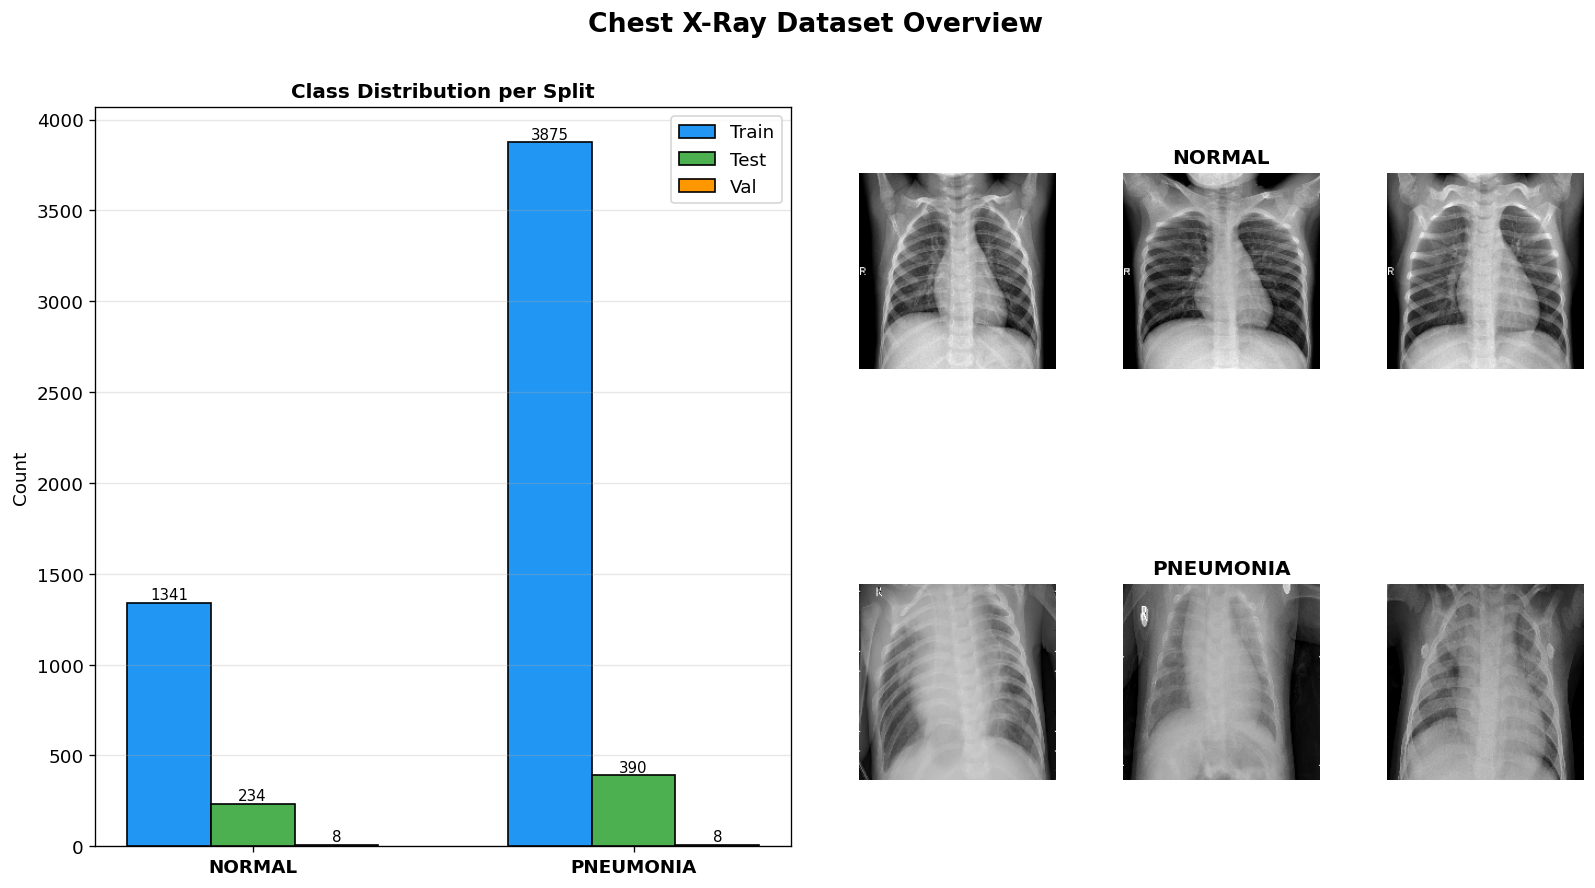

In [12]:
fig=plt.figure(figsize=(16,8))
gs=fig.add_gridspec(2,5,width_ratios=[1.6,1.6,1,1,1],wspace=.28,hspace=.25)

ax=fig.add_subplot(gs[:,0:2])
x=np.arange(len(CLASSES)); w=.22
colors={'Train':'#2196F3','Val':'#FF9800','Test':'#4CAF50'}

for i,(sp,cnt) in enumerate(splits.items()):
    vals=[cnt.get(c,0) for c in CLASSES]
    bars=ax.bar(x+(i-1)*w,vals,w,label=sp,color=colors[sp],edgecolor='black')
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2,b.get_height()+20,int(b.get_height()),
                ha='center',fontsize=9)

ax.set_title('Class Distribution per Split')
ax.set_xticks(x)
ax.set_xticklabels(CLASSES,fontweight='bold')
ax.set_ylabel('Count')
ax.legend()
ax.grid(axis='y',alpha=.3)

for r,cls in enumerate(CLASSES):
    imgs=os.listdir(os.path.join(TRAIN_DIR,cls))[:3]
    for c in range(3):
        ax=fig.add_subplot(gs[r,c+2])
        img=load_img(os.path.join(TRAIN_DIR,cls,imgs[c]),target_size=(180,180))
        ax.imshow(img,cmap='gray')
        ax.axis('off')
        if c==1: ax.set_title(cls,fontweight='bold')

plt.suptitle('Chest X-Ray Dataset Overview',fontsize=16,fontweight='bold')
plt.tight_layout(rect=[0,0,1,.96])
plt.savefig(f'{SAVE_DIR}/01_dataset_overview.png',dpi=300,bbox_inches='tight')
plt.show()

## 🏗️ 2. Build ResNet50 Model

In [13]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary',
    seed=SEED)
test_gen  = test_datagen.flow_from_directory(
    TEST_DIR,  target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary', shuffle=False,
    seed=SEED)

# Class weights for imbalance
n_normal    = train_gen.classes.tolist().count(0)
n_pneumonia = train_gen.classes.tolist().count(1)
total_n     = n_normal + n_pneumonia
class_weights = {0: total_n / (2 * n_normal), 1: total_n / (2 * n_pneumonia)}
print(f'Class weights: {class_weights}')

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class weights: {0: 1.9448173005219984, 1: 0.6730322580645162}


In [14]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
], name='ResNet50_ChestXRay')

model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

model.summary()

Model: "ResNet50_ChestXRay"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d_1  (None, 2048)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_2 (Dense)             (None, 256)               524544    
                                                                 
 batch_normalization_1 (Bat  (None, 256)               1024      
 chNormalization)                                                
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense_3 (Dense)             (None, 1)          

## 🚀 3. Training

In [15]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_auc', patience=3,
                                      restore_best_weights=True, mode='max'),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                          patience=2, min_lr=1e-7, verbose=1)
]

history = model.fit(
    train_gen, epochs=EPOCHS,
    validation_data=test_gen,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/8


163/163 [==============================] - 56s 338ms/step - loss: 0.4512 - accuracy: 0.7778 - auc: 0.8894 - val_loss: 0.6649 - val_accuracy: 0.6154 - val_auc: 0.8907 - lr: 1.0000e-04
Epoch 2/8
163/163 [==============================] - 66s 404ms/step - loss: 0.3579 - accuracy: 0.8374 - auc: 0.9323 - val_loss: 0.6473 - val_accuracy: 0.5721 - val_auc: 0.9089 - lr: 1.0000e-04
Epoch 3/8
163/163 [==============================] - 53s 326ms/step - loss: 0.3255 - accuracy: 0.8604 - auc: 0.9417 - val_loss: 0.4680 - val_accuracy: 0.8413 - val_auc: 0.9174 - lr: 1.0000e-04
Epoch 4/8
163/163 [==============================] - 51s 315ms/step - loss: 0.3039 - accuracy: 0.8723 - auc: 0.9473 - val_loss: 0.4020 - val_accuracy: 0.8109 - val_auc: 0.9195 - lr: 1.0000e-04
Epoch 5/8
163/163 [==============================] - 52s 319ms/step - loss: 0.2788 - accuracy: 0.8848 - auc: 0.9544 - val_loss: 0.3780 - val_accuracy: 0.8221 - val_auc: 0.9264 - lr: 1.0000e-04
Epoch 6/8
163/163 [==========================

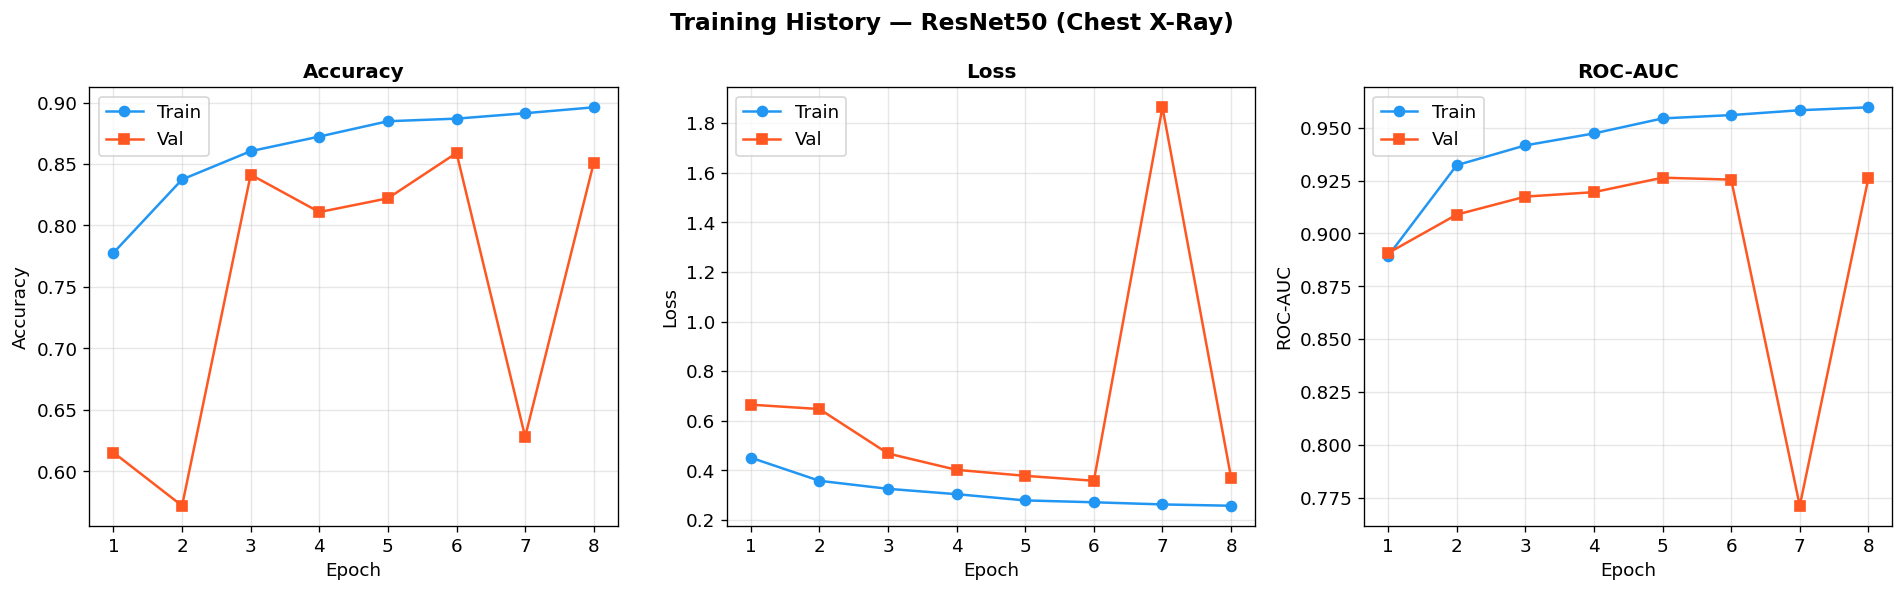

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
eps = range(1, len(history.history['accuracy'])+1)

for ax, (tr_key, vl_key, ylabel) in zip(axes, [
    ('accuracy', 'val_accuracy', 'Accuracy'),
    ('loss',     'val_loss',     'Loss'),
    ('auc',      'val_auc',      'ROC-AUC')
]):
    ax.plot(eps, history.history[tr_key], 'o-', color='#2196F3', label='Train')
    ax.plot(eps, history.history[vl_key], 's-', color='#FF5722', label='Val')
    ax.set_title(ylabel)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Training History — ResNet50 (Chest X-Ray)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/02_training_history.png', bbox_inches='tight')
plt.show()

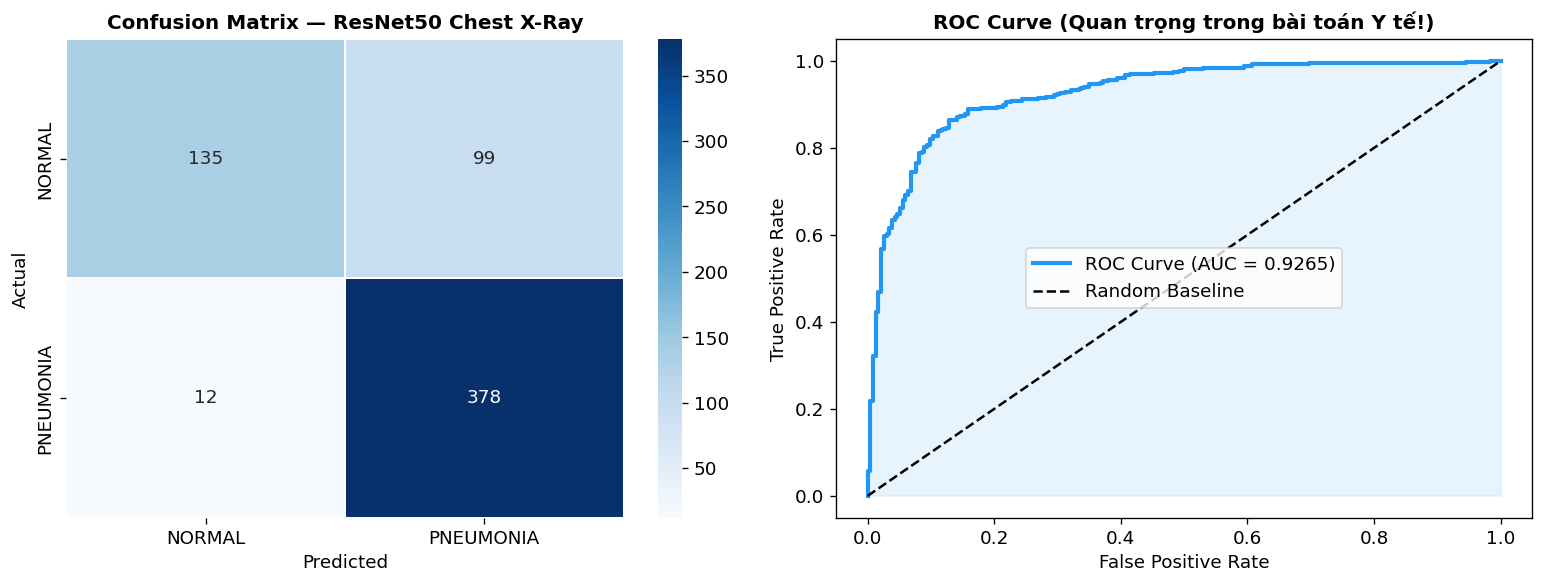

              precision    recall  f1-score   support

      NORMAL       0.92      0.58      0.71       234
   PNEUMONIA       0.79      0.97      0.87       390

    accuracy                           0.82       624
   macro avg       0.86      0.77      0.79       624
weighted avg       0.84      0.82      0.81       624

ROC-AUC: 0.9265


In [17]:
# Evaluate
test_gen.reset()
y_pred_prob = model.predict(test_gen, verbose=0).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)
y_true = test_gen.classes

fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            linewidths=1, ax=axes[0])
axes[0].set_title('Confusion Matrix — ResNet50 Chest X-Ray')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
axes[1].plot(fpr, tpr, color='#2196F3', lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#2196F3')
axes[1].plot([0,1], [0,1], 'k--', lw=1.5, label='Random Baseline')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve (Quan trọng trong bài toán Y tế!)')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/03_confusion_roc.png', bbox_inches='tight')
plt.show()

print(classification_report(y_true, y_pred, target_names=CLASSES))
print(f'ROC-AUC: {roc_auc:.4f}')

In [18]:
with open(f'{SAVE_DIR}/report.txt', 'w') as f:
    f.write('Chest X-Ray Pneumonia Detection — ResNet50\n' + '='*50 + '\n')
    f.write(f'ROC-AUC: {roc_auc:.4f}\n')
    f.write(f'Total Params: {model.count_params():,}\n\n')
    f.write(classification_report(y_true, y_pred, target_names=CLASSES))

print('✅ Chest X-Ray ResNet50 Experiment Completed! Results saved to', SAVE_DIR)

✅ Chest X-Ray ResNet50 Experiment Completed! Results saved to ../results/chest_xray
